<a href="https://colab.research.google.com/github/joh691-ui/PrivPoly1/blob/main/sp500_buypoint_scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 Buy Point Scanner

Scanner som identifierar aktier nära **pragmatiska pivot buy points** enligt en förenklad IBD-inspirerad logik:

**Kriterier för en giltig pivot:**
1. **Konsolidering**: Aktien har handlats inom ett begränsat intervall (drawdown < `MAX_BASE_DEPTH`) under minst `MIN_BASE_DAYS` dagar
2. **Volatilitetskompression**: ATR har komprimerats jämfört med tidigare period
3. **Pivotnivå**: Senaste lokala maxnivå inom basen + 0.10 USD (IBD-konvention)
4. **Närhet till buy zone**: Aktuell kurs inom ±5% från pivot
5. **Trendfilter**: Pris > 50-dagars SMA > 200-dagars SMA (etablerad uppåttrend)

**Output:** Tabell med kandidater + diagram för topp-10

---

*Notera: Detta är en **förenklad** approximation av IBD:s metod. Riktiga IBD buy points kräver mönsterigenkänning av cup-with-handle, flat base m.fl. Detta script fångar generella konsoliderings-breakouts och bör backtestas innan användning i produktion.*

## 1. Installera beroenden

In [16]:
!pip install -q yfinance pandas numpy matplotlib lxml tqdm

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Konfiguration

In [18]:
# --- Pivot-detektering ---
MIN_BASE_DAYS = 25          # Minsta antal dagar för giltig bas (~5 veckor)
MAX_BASE_DAYS = 65          # Max basdjup i dagar (~13 veckor)
MAX_BASE_DEPTH = 0.15       # Max drawdown i basen (15%)
MIN_BASE_DEPTH = 0.05       # Min drawdown (annars är det inte en bas)

# --- Buy zone ---
BUY_ZONE_LOWER = -0.05      # 5% under pivot (närmar sig)
BUY_ZONE_UPPER = 0.05       # 5% över pivot (giltig köpzon enligt IBD)

# --- Volatilitet ---
ATR_COMPRESSION_RATIO = 0.85  # Senaste ATR ska vara <85% av tidigare

# --- Trendfilter ---
REQUIRE_UPTREND = True       # Kräv pris > SMA50 > SMA200

# --- Volym ---
MIN_AVG_VOLUME = 500_000     # Minsta snittvolym (likviditet)

# --- Data ---
LOOKBACK_DAYS = 250          # ~1 års historik

# --- Diagram ---
TOP_N_CHARTS = 10            # Antal diagram att rita

## 3. Hämta S&P 500-listan

In [19]:
import requests
from io import StringIO

def get_sp500_tickers():
    """Hämtar aktuell S&P 500-lista från Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; buy-point-scanner/1.0)'}
    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()
    tables = pd.read_html(StringIO(response.text))
    df = tables[0]
    # yfinance vill ha bindestreck istället för punkter (BRK.B -> BRK-B)
    tickers = df['Symbol'].str.replace('.', '-', regex=False).tolist()
    return tickers, df[['Symbol', 'Security', 'GICS Sector']]

tickers, sp500_info = get_sp500_tickers()
sp500_info['Symbol'] = sp500_info['Symbol'].str.replace('.', '-', regex=False)
print(f'Hittade {len(tickers)} S&P 500-tickers')
sp500_info.head()

Hittade 503 S&P 500-tickers


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


## 4. Hämta prisdata

Batch-download via yfinance. Detta tar 1–3 minuter beroende på Colabs nätverk.

In [20]:
end_date = datetime.now()
start_date = end_date - timedelta(days=int(LOOKBACK_DAYS * 1.6))  # extra marginal för helger

print(f'Hämtar data från {start_date.date()} till {end_date.date()}...')

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by='ticker',
    auto_adjust=True,
    progress=True,
    threads=True,
)

print(f'\nData hämtad. Form: {data.shape}')

Hämtar data från 2025-04-05 till 2026-05-10...


[*********************100%***********************]  503 of 503 completed



Data hämtad. Form: (274, 2515)


## 5. Buy point-detektor

In [21]:
def compute_atr(df, period=14):
    """Average True Range."""
    high_low = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift()).abs()
    low_close = (df['Low'] - df['Close'].shift()).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return tr.rolling(period).mean()


# --- Uppdaterad konfiguration ---
MIN_BASE_DAYS = 25
MAX_BASE_DAYS = 65
MAX_BASE_DEPTH = 0.33      # Tillåt cup-with-handle (var 0.15)
MIN_BASE_DEPTH = 0.05

HANDLE_DAYS = 10           # Längd på handtaget (sista N dagarna)
HANDLE_MAX_DEPTH = 0.12    # Max drawdown i handtaget
HANDLE_ATR_COMPRESSION = 0.90  # Mer tillåtande än hela basen

REQUIRE_UPTREND = True
ALLOW_NEAR_GOLDEN_CROSS = True  # Acceptera om SMA50 inom 5% under SMA200 men stigande


def detect_pivot(df, ticker):
    """
    Detekterar pivot för antingen flat base eller cup-with-handle.
    """
    if df is None or df.empty or len(df) < MAX_BASE_DAYS + 50:
        return None

    df = df.copy().dropna(subset=['Close', 'High', 'Low', 'Volume'])
    if len(df) < MAX_BASE_DAYS + 50:
        return None

    avg_vol = df['Volume'].tail(50).mean()
    if avg_vol < MIN_AVG_VOLUME:
        return None

    sma50 = df['Close'].rolling(50).mean()
    sma200 = df['Close'].rolling(200).mean()
    last_close = df['Close'].iloc[-1]

    # Flexiblare trendfilter
    if REQUIRE_UPTREND:
        if pd.isna(sma200.iloc[-1]):
            return None
        strong_uptrend = last_close > sma50.iloc[-1] > sma200.iloc[-1]
        # Tillåt early uptrend: pris > SMA50, SMA50 stiger, inom 5% under SMA200
        sma50_rising = sma50.iloc[-1] > sma50.iloc[-10]
        near_golden_cross = (
            ALLOW_NEAR_GOLDEN_CROSS and
            last_close > sma50.iloc[-1] and
            sma50_rising and
            sma50.iloc[-1] >= sma200.iloc[-1] * 0.95
        )
        if not (strong_uptrend or near_golden_cross):
            return None

    atr = compute_atr(df)
    best = None

    for base_len in range(MIN_BASE_DAYS, min(MAX_BASE_DAYS, len(df) - 1) + 1, 5):
        base_window = df.iloc[-base_len:]
        base_high = base_window['High'].max()
        base_low = base_window['Low'].min()
        depth = (base_high - base_low) / base_high

        if not (MIN_BASE_DEPTH <= depth <= MAX_BASE_DEPTH):
            continue

        # --- Två kandidat-pivots ---
        # A) Flat base / cup: pivot = basens topp + 0.10
        flat_pivot = base_high + 0.10

        # B) Cup-with-handle: leta efter handle de sista HANDLE_DAYS dagarna
        handle = base_window.tail(HANDLE_DAYS)
        handle_high = handle['High'].max()
        handle_low = handle['Low'].min()
        handle_depth = (handle_high - handle_low) / handle_high
        handle_pivot = handle_high + 0.10

        # Giltigt handtag: grunt drawdown OCH lägre än basens topp
        valid_handle = (
            handle_depth <= HANDLE_MAX_DEPTH and
            handle_high < base_high and
            handle_high > base_high * 0.88  # Handle ska vara i övre delen av basen
        )

        # ATR-kompression i handtaget (bara handtagets dagar)
        recent_atr = atr.iloc[-HANDLE_DAYS:].mean()
        prior_atr = atr.iloc[-base_len:-HANDLE_DAYS].mean()
        if pd.isna(recent_atr) or pd.isna(prior_atr) or prior_atr == 0:
            continue
        handle_atr_ratio = recent_atr / prior_atr

        # Testa båda pivots
        for pattern, pivot, atr_threshold, depth_for_score in [
            ('flat_base', flat_pivot, ATR_COMPRESSION_RATIO, depth),
            ('cup_handle', handle_pivot, HANDLE_ATR_COMPRESSION, handle_depth),
        ]:
            if pattern == 'cup_handle' and not valid_handle:
                continue

            dist = (last_close - pivot) / pivot
            if not (BUY_ZONE_LOWER <= dist <= BUY_ZONE_UPPER):
                continue

            if handle_atr_ratio > atr_threshold:
                continue

            recent_vol = base_window['Volume'].tail(10).mean()
            early_vol = base_window['Volume'].head(10).mean()
            vol_decline = recent_vol / early_vol if early_vol > 0 else 1.0

            proximity_score = 1 - abs(dist) * 10
            compression_score = 1 - handle_atr_ratio
            depth_score = 1 - depth_for_score / MAX_BASE_DEPTH
            score = (proximity_score + compression_score + depth_score) / 3

            candidate = {
                'ticker': ticker,
                'pattern': pattern,
                'last_close': last_close,
                'pivot': pivot,
                'dist_to_pivot_pct': dist * 100,
                'base_days': base_len,
                'base_depth_pct': depth * 100,
                'handle_depth_pct': handle_depth * 100 if pattern == 'cup_handle' else None,
                'handle_atr_ratio': handle_atr_ratio,
                'vol_decline_ratio': vol_decline,
                'avg_volume': avg_vol,
                'sma50': sma50.iloc[-1],
                'sma200': sma200.iloc[-1],
                'score': score,
            }

            if best is None or candidate['score'] > best['score']:
                best = candidate

    return best

## 6. Kör scannern över alla S&P 500-aktier

In [22]:
candidates = []
errors = []

for ticker in tqdm(tickers, desc='Skannar'):
    try:
        if ticker not in data.columns.get_level_values(0):
            continue
        df = data[ticker].dropna(how='all')
        result = detect_pivot(df, ticker)
        if result is not None:
            candidates.append(result)
    except Exception as e:
        errors.append((ticker, str(e)))

print(f'\n{len(candidates)} kandidater hittade.')
if errors:
    print(f'{len(errors)} fel uppstod (visar de första 5):')
    for t, e in errors[:5]:
        print(f'  {t}: {e}')

Skannar:   0%|          | 0/503 [00:00<?, ?it/s]


36 kandidater hittade.


## 7. Sammanställ tabell

In [24]:
cols = ['ticker', 'name', 'sector', 'pattern', 'last_close', 'pivot', 'dist_to_pivot_pct',
        'base_days', 'base_depth_pct', 'handle_depth_pct', 'handle_atr_ratio',
        'vol_decline_ratio', 'avg_volume', 'score']
results_df = results_df[cols]

print(f'\n=== TOP {min(30, len(results_df))} BUY POINT-KANDIDATER ===\n')
display(results_df.head(30).style.format({
    'last_close': '${:.2f}',
    'pivot': '${:.2f}',
    'dist_to_pivot_pct': '{:+.2f}%',
    'base_depth_pct': '{:.1f}%',
    'handle_depth_pct': lambda x: f'{x:.1f}%' if pd.notna(x) else '—',
    'handle_atr_ratio': '{:.2f}',
    'vol_decline_ratio': '{:.2f}',
    'avg_volume': '{:,.0f}',
    'score': '{:.3f}',
}))


=== TOP 30 BUY POINT-KANDIDATER ===



,ticker,name,sector,pattern,last_close,pivot,dist_to_pivot_pct,base_days,base_depth_pct,handle_depth_pct,handle_atr_ratio,vol_decline_ratio,avg_volume,score
0,GS,Goldman Sachs,Financials,cup_handle,$936.48,$945.40,-0.94%,60,19.0%,4.9%,0.74,0.75,"2,197,436",0.671
1,SBAC,SBA Communications,Real Estate,cup_handle,$218.17,$222.68,-2.03%,25,9.8%,4.2%,0.68,0.47,"1,265,030",0.664
2,SATS,EchoStar,Communication Services,cup_handle,$127.15,$127.36,-0.16%,25,15.4%,8.4%,0.81,0.82,"6,524,892",0.641
3,FOX,Fox Corporation (Class B),Communication Services,cup_handle,$56.60,$57.85,-2.16%,60,17.9%,4.5%,0.81,0.44,"1,584,966",0.614
4,SPG,Simon Property Group,Real Estate,cup_handle,$202.12,$206.34,-2.05%,60,14.6%,3.8%,0.86,0.78,"1,543,084",0.605
5,EXR,Extra Space Storage,Real Estate,cup_handle,$143.30,$145.65,-1.61%,55,16.8%,5.2%,0.87,1.06,"1,227,352",0.603
6,WMT,Walmart,Consumer Staples,cup_handle,$130.43,$133.22,-2.09%,60,12.2%,5.6%,0.82,0.51,"18,334,718",0.599
7,USB,U.S. Bancorp,Financials,cup_handle,$55.53,$57.15,-2.83%,55,14.5%,3.8%,0.81,0.85,"9,924,384",0.598
8,FOXA,Fox Corporation (Class A),Communication Services,cup_handle,$62.94,$64.75,-2.80%,60,20.0%,5.3%,0.81,0.54,"3,503,596",0.585
9,KVUE,Kenvue,Consumer Staples,cup_handle,$17.59,$17.99,-2.22%,65,13.2%,4.9%,0.89,0.29,"20,699,864",0.580


## 8. Diagram för topp-kandidater

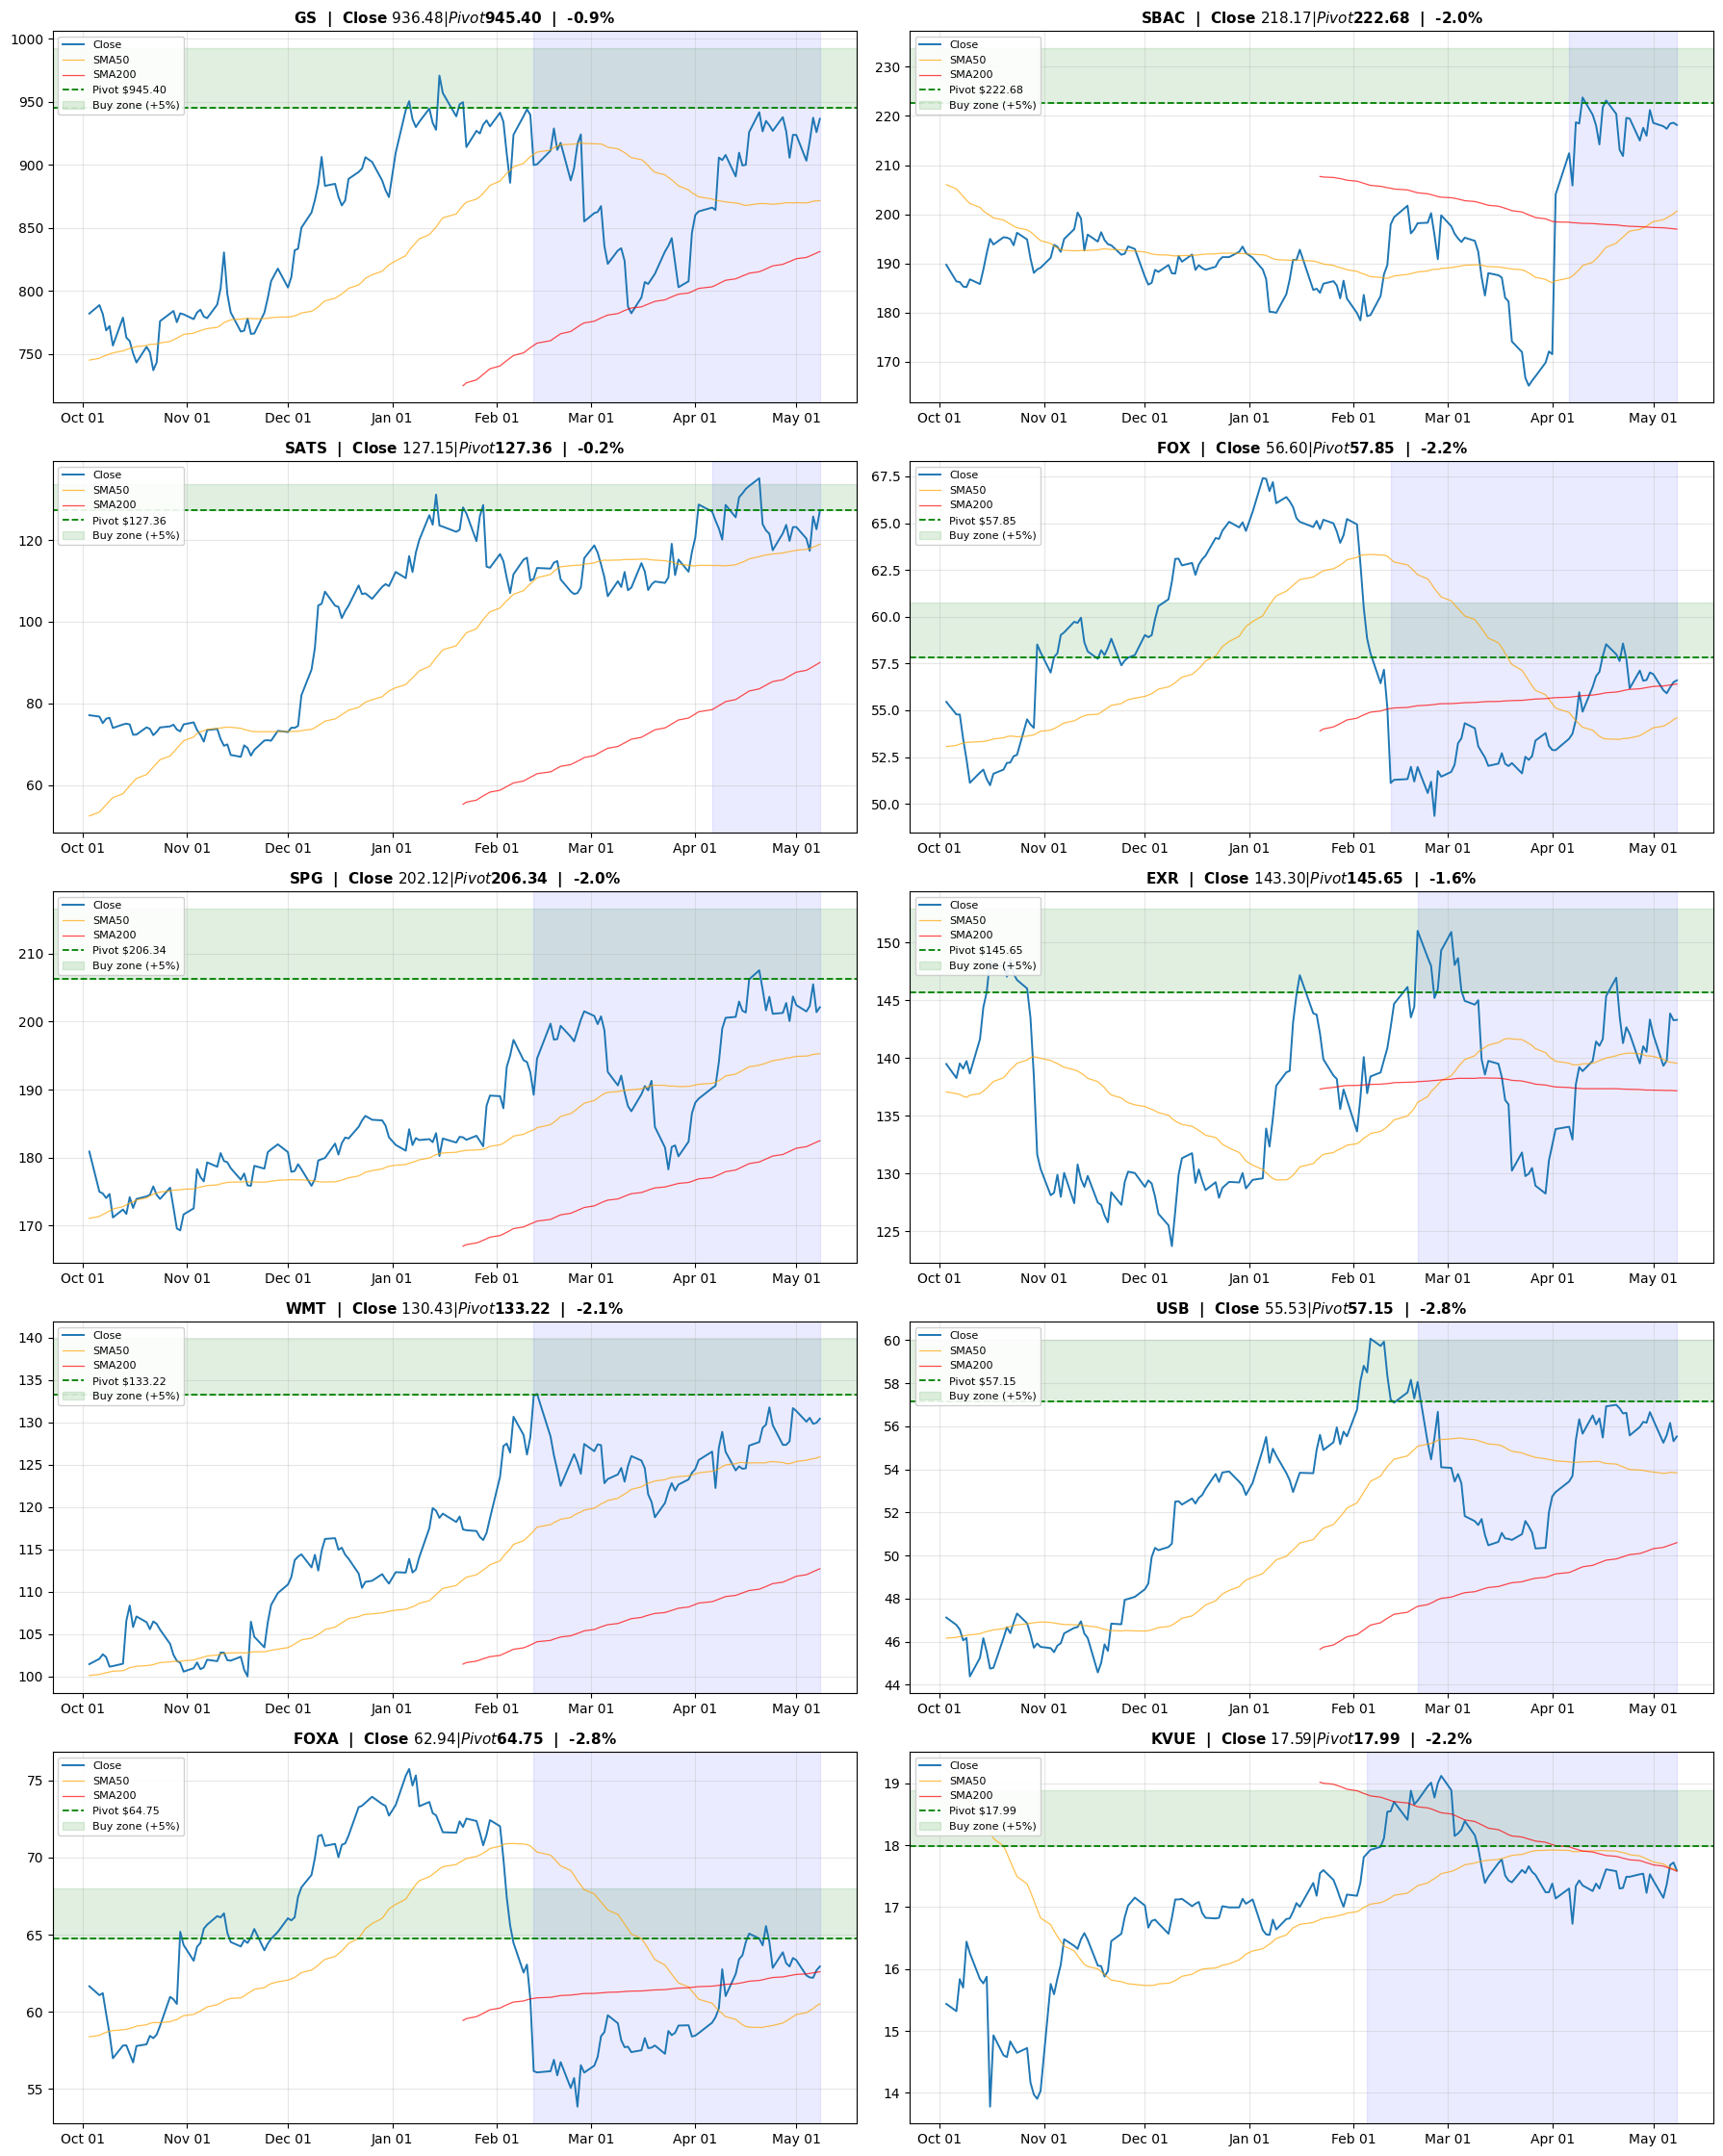

In [25]:
def plot_candidate(ticker, df, pivot, base_days, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 5))

    plot_df = df.tail(150).copy()
    base_start_idx = len(plot_df) - base_days if base_days < len(plot_df) else 0

    # Pris
    ax.plot(plot_df.index, plot_df['Close'], color='#1f77b4', linewidth=1.4, label='Close')

    # SMA50, SMA200
    sma50 = df['Close'].rolling(50).mean().tail(150)
    sma200 = df['Close'].rolling(200).mean().tail(150)
    ax.plot(plot_df.index, sma50, color='orange', linewidth=0.9, alpha=0.7, label='SMA50')
    ax.plot(plot_df.index, sma200, color='red', linewidth=0.9, alpha=0.7, label='SMA200')

    # Pivot-linje
    ax.axhline(pivot, color='green', linestyle='--', linewidth=1.3, label=f'Pivot ${pivot:.2f}')
    ax.axhspan(pivot, pivot * 1.05, alpha=0.12, color='green', label='Buy zone (+5%)')

    # Markera basen
    ax.axvspan(plot_df.index[base_start_idx], plot_df.index[-1], alpha=0.08, color='blue')

    last_close = plot_df['Close'].iloc[-1]
    dist = (last_close - pivot) / pivot * 100
    ax.set_title(f'{ticker}  |  Close ${last_close:.2f}  |  Pivot ${pivot:.2f}  |  {dist:+.1f}%',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())


if not results_df.empty:
    top = results_df.head(TOP_N_CHARTS)
    n_rows = (len(top) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 4.5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(top) == 1 else axes

    for i, (_, row) in enumerate(top.iterrows()):
        df_t = data[row['ticker']].dropna(how='all')
        plot_candidate(row['ticker'], df_t, row['pivot'], int(row['base_days']), ax=axes[i])

    # Dölj eventuell oanvänd subplot
    for j in range(len(top), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('Inga kandidater att visa.')

## 9. (Valfritt) Spara resultat till CSV

In [26]:
if not results_df.empty:
    fname = f'sp500_buypoints_{datetime.now().strftime("%Y%m%d")}.csv'
    results_df.to_csv(fname, index=False)
    print(f'Sparat: {fname}')

    # I Colab: ladda ner till lokal disk
    try:
        from google.colab import files
        files.download(fname)
    except ImportError:
        pass

Sparat: sp500_buypoints_20260510.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Anteckningar för vidareutveckling

- **Backtest**: Detta script identifierar kandidater i nuet men säger inget om historisk träffsäkerhet. Innan man agerar på signalerna bör man backtesta logiken över 5–10 år för att verifiera att den faktiskt ger en edge efter transaktionskostnader.
- **Volymbekräftelse vid breakout**: Riktig IBD-metod kräver att utbrytningen sker med ≥40% över snittvolymen. Det fångar denna scanner inte — den letar bara efter aktier *nära* pivot.
- **Mönsterigenkänning**: För att skilja cup-with-handle från flat base krävs faktisk formdetektering (t.ex. via scipy.signal.find_peaks eller approximerad med U-form-fitting).
- **Relativ styrka**: IBD kräver att RS-ranking > 80 vs marknaden. Lätt att lägga till genom att jämföra 6/12-månaders avkastning vs SPY-percentil.
- **Falska utbrytningar**: Många pivots går sönder i sidledes marknader. Ett marknadsregimfilter (HMM eller enkel SPY > SMA200) skulle förbättra signalkvaliteten.


In [28]:
def diagnose_v2(ticker, df):
    print(f'\n=== DIAGNOS: {ticker} ===')
    if df is None or df.empty or len(df) < MAX_BASE_DAYS + 50:
        print(f'  För lite data')
        return

    df = df.copy().dropna(subset=['Close', 'High', 'Low', 'Volume'])
    last_close = df['Close'].iloc[-1]
    sma50 = df['Close'].rolling(50).mean()
    sma200 = df['Close'].rolling(200).mean()

    print(f'  Last close: ${last_close:.2f}')
    print(f'  SMA50: ${sma50.iloc[-1]:.2f}  |  SMA200: ${sma200.iloc[-1]:.2f}')
    strong = last_close > sma50.iloc[-1] > sma200.iloc[-1]
    sma50_rising = sma50.iloc[-1] > sma50.iloc[-10]
    near_gc = (last_close > sma50.iloc[-1] and sma50_rising
               and sma50.iloc[-1] >= sma200.iloc[-1] * 0.95)
    print(f'  Strong uptrend: {strong}  |  Near golden cross: {near_gc}')

    atr = compute_atr(df)

    print(f'\n  {"days":>5} {"depth":>7} {"flat_pv":>9} {"hndl_pv":>9} {"hndl_d":>7} {"hndl_atr":>8} {"valid_h":>8}')
    for base_len in range(MIN_BASE_DAYS, MAX_BASE_DAYS + 1, 5):
        bw = df.iloc[-base_len:]
        bh = bw['High'].max()
        depth = (bh - bw['Low'].min()) / bh
        handle = bw.tail(HANDLE_DAYS)
        hh = handle['High'].max()
        hd = (hh - handle['Low'].min()) / hh
        valid_h = hd <= HANDLE_MAX_DEPTH and hh < bh and hh > bh * 0.88

        recent_atr = atr.iloc[-HANDLE_DAYS:].mean()
        prior_atr = atr.iloc[-base_len:-HANDLE_DAYS].mean()
        h_atr = recent_atr / prior_atr if prior_atr > 0 else float('nan')

        print(f'  {base_len:>5} {depth*100:>6.1f}% ${bh+0.10:>7.2f} ${hh+0.10:>7.2f} '
              f'{hd*100:>6.1f}% {h_atr:>7.2f} {"YES" if valid_h else "no":>8}')


for tkr in ['BA', 'NVDA', 'AAPL']:
    if tkr in data.columns.get_level_values(0):
        diagnose_v2(tkr, data[tkr].dropna(how='all'))


=== DIAGNOS: BA ===
  Last close: $237.36
  SMA50: $217.23  |  SMA200: $219.60
  Strong uptrend: False  |  Near golden cross: False

   days   depth   flat_pv   hndl_pv  hndl_d hndl_atr  valid_h
     25   13.3% $ 238.64 $ 238.64    7.3%    1.02       no
     30   21.3% $ 238.64 $ 238.64    7.3%    1.01       no
     35   21.3% $ 238.64 $ 238.64    7.3%    0.98       no
     40   21.3% $ 238.64 $ 238.64    7.3%    0.96       no
     45   21.3% $ 238.64 $ 238.64    7.3%    0.96       no
     50   21.3% $ 238.64 $ 238.64    7.3%    0.97       no
     55   21.3% $ 238.64 $ 238.64    7.3%    0.97       no
     60   23.8% $ 246.61 $ 238.64    7.3%    0.95      YES
     65   24.3% $ 247.96 $ 238.64    7.3%    0.95      YES

=== DIAGNOS: NVDA ===
  Last close: $215.20
  SMA50: $188.65  |  SMA200: $184.72
  Strong uptrend: True  |  Near golden cross: True

   days   depth   flat_pv   hndl_pv  hndl_d hndl_atr  valid_h
     25   20.3% $ 217.90 $ 217.90   10.6%    1.27       no
     30   24.6% $ 